In [76]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from data_utils import y_weighted_fill_or_smooth, find_congestion_blocks_merged, filter_congestion_blocks, plot_matrix, process_pems

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 13,
    "figure.facecolor": "white",
})

data_dir = Path("data/pems/5_min")
station_data_path = Path("data/pems/district12_stations.txt")
output_dir = Path("data/pems")
selected_day = "2026_04_13"
selected_date = pd.Timestamp(selected_day.replace("_", "-"))
detector_data_path = data_dir / f"d12_text_station_5min_{selected_day}.txt"
# speed_matrix_path = output_dir / f"speed_matrix_5_min_{selected_day}.npy"
# flow_matrix_path = output_dir / f"flow_matrix_5_min_{selected_day}.npy"

cols = [
    "timestamp",
    "station_id",
    "district",
    "freeway",
    "direction_of_travel",
    "lane_type",
    "station_length",
    "samples",
    "percent_observed",
    "total_flow",
    "avg_occupancy",
    "avg_speed",
    "lane_1_samples",
    "lane_1_flow",
    "lane_1_avg_occupancy",
    "lane_1_avg_speed",
    "lane_1_observed",
    "lane_2_samples",
    "lane_2_flow",
    "lane_2_avg_occupancy",
    "lane_2_avg_speed",
    "lane_2_observed",    
    "lane_3_samples",
    "lane_3_flow",
    "lane_3_avg_occupancy",
    "lane_3_avg_speed",
    "lane_3_observed",
    "lane_4_samples",
    "lane_4_flow",
    "lane_4_avg_occupancy",
    "lane_4_avg_speed",
    "lane_4_observed",   
    "lane_5_samples",
    "lane_5_flow",
    "lane_5_avg_occupancy",
    "lane_5_avg_speed",
    "lane_5_observed",
    "lane_6_samples",
    "lane_6_flow",
    "lane_6_avg_occupancy",
    "lane_6_avg_speed",
    "lane_6_observed",
    "lane_7_samples",
    "lane_7_flow",
    "lane_7_avg_occupancy",
    "lane_7_avg_speed",
    "lane_7_observed",
    "lane_8_samples",
    "lane_8_flow",
    "lane_8_avg_occupancy",
    "lane_8_avg_speed",
    "lane_8_observed"
]

if not detector_data_path.exists():
    raise FileNotFoundError(f"Could not find {detector_data_path}")

with detector_data_path.open("r") as f:
    first = f.readline()
sep = "\t" if first.count("\t") > first.count(",") else ","

master_df = pd.read_csv(
    detector_data_path,
    sep=sep,
    header=None,
    names=cols,
    low_memory=False,
)

print(f"Loaded {detector_data_path.name} for {selected_date.date()}")

Loaded d12_text_station_5min_2026_04_13.txt for 2026-04-13


In [2]:
master_df.head()

,timestamp,station_id,district,freeway,direction_of_travel,lane_type,station_length,samples,percent_observed,total_flow,...,lane_7_samples,lane_7_flow,lane_7_avg_occupancy,lane_7_avg_speed,lane_7_observed,lane_8_samples,lane_8_flow,lane_8_avg_occupancy,lane_8_avg_speed,lane_8_observed
0,04/14/2026 00:00:00,1201044,12,133,S,OR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
1,04/14/2026 00:00:00,1201052,12,133,S,FR,NaN,0,0,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
2,04/14/2026 00:00:00,1201054,12,133,S,ML,1.285,0,0,35.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
3,04/14/2026 00:00:00,1201058,12,133,N,OR,NaN,10,100,4.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0
4,04/14/2026 00:00:00,1201064,12,133,N,FR,NaN,10,100,1.0,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0


In [77]:
# Filter: freeway == 5 and direction_of_travel == "S" for one selected day.
# Cast freeway to numeric in case it was read as string.
master_df["freeway"] = pd.to_numeric(master_df["freeway"], errors="coerce")
master_df["direction_of_travel"] = master_df["direction_of_travel"].astype(str).str.strip().str.upper()
master_df["lane_type"] = master_df["lane_type"].astype(str).str.strip().str.upper()

master_df["timestamp"] = pd.to_datetime(master_df["timestamp"], errors="coerce")
master_df = master_df[
    (master_df["timestamp"].dt.date == selected_date.date()) &
    (master_df["timestamp"].dt.hour >= 0) &
    (master_df["timestamp"].dt.hour < 24) &
    ((master_df["lane_type"] == "ML") | (master_df["lane_type"] == "HV"))
].copy()

i5_s = master_df[
    (master_df["freeway"] == 5) &
    (master_df["direction_of_travel"] == "S") 
].copy()

i5_n = master_df[
    (master_df["freeway"] == 5) &
    (master_df["direction_of_travel"] == "N") 
].copy()

# for i5_s and i5_n, first get the number of lanes with non-null flow samples for each row. then, add a column called flow_per_lane that is the
# total_flow / number of lanes with non-null flow samples

i5_s['num_lanes'] = i5_s[[f"lane_{lane}_flow" for lane in range(1, 9)]].notnull().sum(axis=1)
i5_n['num_lanes'] = i5_n[[f"lane_{lane}_flow" for lane in range(1, 9)]].notnull().sum(axis=1)

i5_s['flow_per_lane'] = i5_s['total_flow'] / i5_s['num_lanes'] 
i5_n['flow_per_lane'] = i5_n['total_flow'] / i5_n['num_lanes'] 

i5_s['flow_per_lane'] = i5_s['flow_per_lane'] * 20 # veh/hr
i5_n['flow_per_lane'] = i5_n['flow_per_lane'] * 20 # veh/hr

i5_s['total_flow'] = i5_s['total_flow'] * 20 # veh/hr
i5_n['total_flow'] = i5_n['total_flow'] * 20 # veh/hr

for lane in range(1, 9):
    flow_col = f"lane_{lane}_flow"
    speed_col = f"lane_{lane}_avg_speed"
    density_col = f"lane_{lane}_density"
    i5_s[density_col] = i5_s[flow_col] * 20  / i5_s[speed_col] # veh/mi/lane
    i5_n[density_col] = i5_n[flow_col] * 20  / i5_n[speed_col] # veh/mi/lane

density_cols = [f"lane_{lane}_density" for lane in range(1, 9)]
i5_s["avg_density"] = i5_s[density_cols].mean(axis=1, skipna=True)
i5_n["avg_density"] = i5_n[density_cols].mean(axis=1, skipna=True)
i5_s = i5_s[["timestamp", "station_id", "lane_type", "total_flow", "flow_per_lane", "avg_speed", "samples","percent_observed", 'avg_density', 'num_lanes']]
i5_n = i5_n[["timestamp", "station_id", "lane_type", "total_flow", "flow_per_lane", "avg_speed", "samples","percent_observed", 'avg_density', 'num_lanes']]
i5_s.head()

,timestamp,station_id,lane_type,total_flow,flow_per_lane,avg_speed,samples,percent_observed,avg_density,num_lanes
666,2026-04-13,1204193,ML,2140.0,535.0,67.5,39,100,7.952670,4
671,2026-04-13,1204216,ML,1680.0,420.0,69.1,36,100,6.093843,4
681,2026-04-13,1204273,ML,1580.0,395.0,70.8,35,100,5.596585,4
684,2026-04-13,1204306,ML,1760.0,440.0,69.2,37,100,6.383228,4
692,2026-04-13,1204345,ML,1980.0,396.0,70.7,49,80,5.629321,5


In [78]:
i5_s["percent_observed"].describe()
print('sensor readings where the percent observed is 0:',len(i5_s[i5_s["percent_observed"]==0]) / len(i5_s))
i5_s = i5_s[i5_s["percent_observed"] != 0].copy()

sensor readings where the percent observed is 0: 0.1667135885885886


In [79]:
station_counts = (
    i5_s.groupby("station_id")
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

expected_rows_per_station = i5_s["timestamp"].nunique()
print("Expected 5-minute rows per station:", expected_rows_per_station)
station_counts['percentage'] = station_counts["row_count"] / expected_rows_per_station
station_counts['percentage'].describe()

Expected 5-minute rows per station: 288


count    185.000000
mean       0.999944
std        0.000766
min        0.989583
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: percentage, dtype: float64

In [80]:
# list of station_ids where percentage < 0.7
high_pct_station_ids = station_counts.loc[
    station_counts["percentage"] > 0.7, "station_id"
].tolist()

# filter i5_s to only those station_ids
i5_s = i5_s[i5_s["station_id"].isin(high_pct_station_ids)].copy()

In [81]:
# Load station metadata for the selected corridor.
stations = pd.read_csv(station_data_path, sep="\t")
rename_map = {col: col.lower().replace(" ", "_") for col in stations.columns}
stations.rename(columns=rename_map, inplace=True)
stations.rename(columns={"id": "station_id"}, inplace=True)

# Infer the direction of the postmile progression
postmile_dxn = -1

# Filter to correct fwy and direction mainline/HOV stations within the desired postmile window.
stations = stations[(stations["fwy"] == 5) & ((stations["dir"] == 'S') | (stations["dir"] == 'N'))]
stations = stations[stations["type"].isin(["ML", "HV"])]

# Quick sanity check on mainline detector spacing.
print("Summary of station lengths:\n", stations["length"].describe())

i5_s = i5_s.merge(stations[["station_id", "abs_pm"]], on="station_id", how="left")
i5_n = i5_n.merge(stations[["station_id", "abs_pm"]], on="station_id", how="left")
i5_s.head()

Summary of station lengths:
 count    446.000000
mean       0.395004
std        0.221450
min        0.079000
25%        0.275750
50%        0.370000
75%        0.475000
max        2.665000
Name: length, dtype: float64


,timestamp,station_id,lane_type,total_flow,flow_per_lane,avg_speed,samples,percent_observed,avg_density,num_lanes,abs_pm
0,2026-04-13,1204193,ML,2140.0,535.0,67.5,39,100,7.952670,4,72.835
1,2026-04-13,1204216,ML,1680.0,420.0,69.1,36,100,6.093843,4,73.455
2,2026-04-13,1204273,ML,1580.0,395.0,70.8,35,100,5.596585,4,75.755
3,2026-04-13,1204306,ML,1760.0,440.0,69.2,37,100,6.383228,4,77.595
4,2026-04-13,1204345,ML,1980.0,396.0,70.7,49,80,5.629321,5,78.665


In [82]:
# divide the i5_s and i5_n df into two dfs: one with ML stations, and the other with HV stations. then do a join by abs_pm so that hv and ml stations with the same pm are on the same row.
# stations without a matching pair should still make it into the merged df

i5_s_ml = i5_s[i5_s["lane_type"] == "ML"]
i5_s_hv = i5_s[i5_s["lane_type"] == "HV"]
i5_n_ml = i5_n[i5_n["lane_type"] == "ML"]
i5_n_hv = i5_n[i5_n["lane_type"] == "HV"]

i5_s_merged = i5_s_ml.merge(i5_s_hv, on=["abs_pm", "timestamp"], suffixes=("_ml", "_hv"), how="outer")
i5_n_merged = i5_n_ml.merge(i5_n_hv, on=["abs_pm", "timestamp"], suffixes=("_ml", "_hv"), how="outer")

# write summary about the merge (ie, how many rows had both ml and hv data, how many had only ml, how many had only hv)
i5_s_merged_summary = {
    "both": i5_s_merged[i5_s_merged["flow_per_lane_ml"].notnull() & i5_s_merged["flow_per_lane_hv"].notnull()].shape[0],
    "only_ml": i5_s_merged[i5_s_merged["flow_per_lane_ml"].notnull() & i5_s_merged["flow_per_lane_hv"].isnull()].shape[0],
    "only_hv": i5_s_merged[i5_s_merged["flow_per_lane_ml"].isnull() & i5_s_merged["flow_per_lane_hv"].notnull()].shape[0]
}

i5_n_merged_summary = {
    "both": i5_n_merged[i5_n_merged["flow_per_lane_ml"].notnull() & i5_n_merged["flow_per_lane_hv"].notnull()].shape[0],
    "only_ml": i5_n_merged[i5_n_merged["flow_per_lane_ml"].notnull() & i5_n_merged["flow_per_lane_hv"].isnull()].shape[0],
    "only_hv": i5_n_merged[i5_n_merged["flow_per_lane_ml"].isnull() & i5_n_merged["flow_per_lane_hv"].notnull()].shape[0]
}

#print the summary
print("I-5 South Merged Summary:")
print(i5_s_merged_summary)

print("I-5 North Merged Summary:")
print(i5_n_merged_summary)

I-5 South Merged Summary:
{'both': 21309, 'only_ml': 7203, 'only_hv': 3456}
I-5 North Merged Summary:
{'both': 29088, 'only_ml': 4608, 'only_hv': 4032}


In [22]:
i5_s_merged.head()

,timestamp,station_id_ml,lane_type_ml,total_flow_ml,flow_per_lane_ml,avg_speed_ml,samples_ml,percent_observed_ml,avg_density_ml,num_lanes_ml,abs_pm,station_id_hv,lane_type_hv,total_flow_hv,flow_per_lane_hv,avg_speed_hv,samples_hv,percent_observed_hv,avg_density_hv,num_lanes_hv
0,2026-04-15 00:00:00,1204193.0,ML,1360.0,340.0,67.5,40.0,100.0,5.058619,4.0,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-15 00:05:00,1204193.0,ML,1100.0,275.0,67.8,40.0,100.0,4.074384,4.0,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-04-15 00:10:00,1204193.0,ML,1500.0,375.0,69.6,39.0,100.0,5.431476,4.0,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-04-15 00:15:00,1204193.0,ML,1020.0,255.0,67.6,38.0,100.0,3.790829,4.0,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-15 00:20:00,1204193.0,ML,1420.0,355.0,68.3,40.0,100.0,5.231542,4.0,72.835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
# create merged metrics by weighting ML and HV contributions by the number of valid lanes.
def weighted_merge(df, ml_col, hv_col, ml_weight_col, hv_weight_col):
    ml_weight = df[ml_weight_col].where(df[ml_col].notna(), 0).fillna(0)
    hv_weight = df[hv_weight_col].where(df[hv_col].notna(), 0).fillna(0)
    total_weight = ml_weight + hv_weight
    merged = (
        df[ml_col].fillna(0) * ml_weight + df[hv_col].fillna(0) * hv_weight
    ) / total_weight
    return merged.where(total_weight > 0, np.nan)

i5_s_merged["flow_per_lane"] = weighted_merge(
    i5_s_merged, "flow_per_lane_ml", "flow_per_lane_hv", "num_lanes_ml", "num_lanes_hv"
)
i5_n_merged["flow_per_lane"] = weighted_merge(
    i5_n_merged, "flow_per_lane_ml", "flow_per_lane_hv", "num_lanes_ml", "num_lanes_hv"
)

i5_s_merged["avg_speed"] = weighted_merge(
    i5_s_merged, "avg_speed_ml", "avg_speed_hv", "num_lanes_ml", "num_lanes_hv"
)
i5_n_merged["avg_speed"] = weighted_merge(
    i5_n_merged, "avg_speed_ml", "avg_speed_hv", "num_lanes_ml", "num_lanes_hv"
)

i5_s_merged["avg_density"] = weighted_merge(
    i5_s_merged, "avg_density_ml", "avg_density_hv", "num_lanes_ml", "num_lanes_hv"
)
i5_n_merged["avg_density"] = weighted_merge(
    i5_n_merged, "avg_density_ml", "avg_density_hv", "num_lanes_ml", "num_lanes_hv"
)

# only grab relevant columns for final output
i5_s_merged = i5_s_merged[["timestamp", "station_id_ml", "station_id_hv", "flow_per_lane", "avg_speed", "avg_density", "abs_pm"]]
i5_n_merged = i5_n_merged[["timestamp", "station_id_ml", "station_id_hv", "flow_per_lane", "avg_speed", "avg_density", "abs_pm"]]

In [45]:
i5_s_merged.head()

,timestamp,station_id_ml,station_id_hv,flow_per_lane,avg_speed,avg_density,abs_pm
0,2026-04-16 00:00:00,1204193.0,NaN,285.0,67.9,4.215193,72.835
1,2026-04-16 00:05:00,1204193.0,NaN,295.0,68.4,4.329857,72.835
2,2026-04-16 00:10:00,1204193.0,NaN,335.0,68.6,4.910045,72.835
3,2026-04-16 00:15:00,1204193.0,NaN,295.0,67.1,4.411064,72.835
4,2026-04-16 00:20:00,1204193.0,NaN,220.0,67.5,3.269849,72.835


2026-04-13 00:00:00 2026-04-13 23:55:00
288.0 175.22945229178708
inferred time increment: 0 days 00:05:00
inferred space increment: -0.4 km
num time bins: 287
num space bins: 176
num space edges: 176


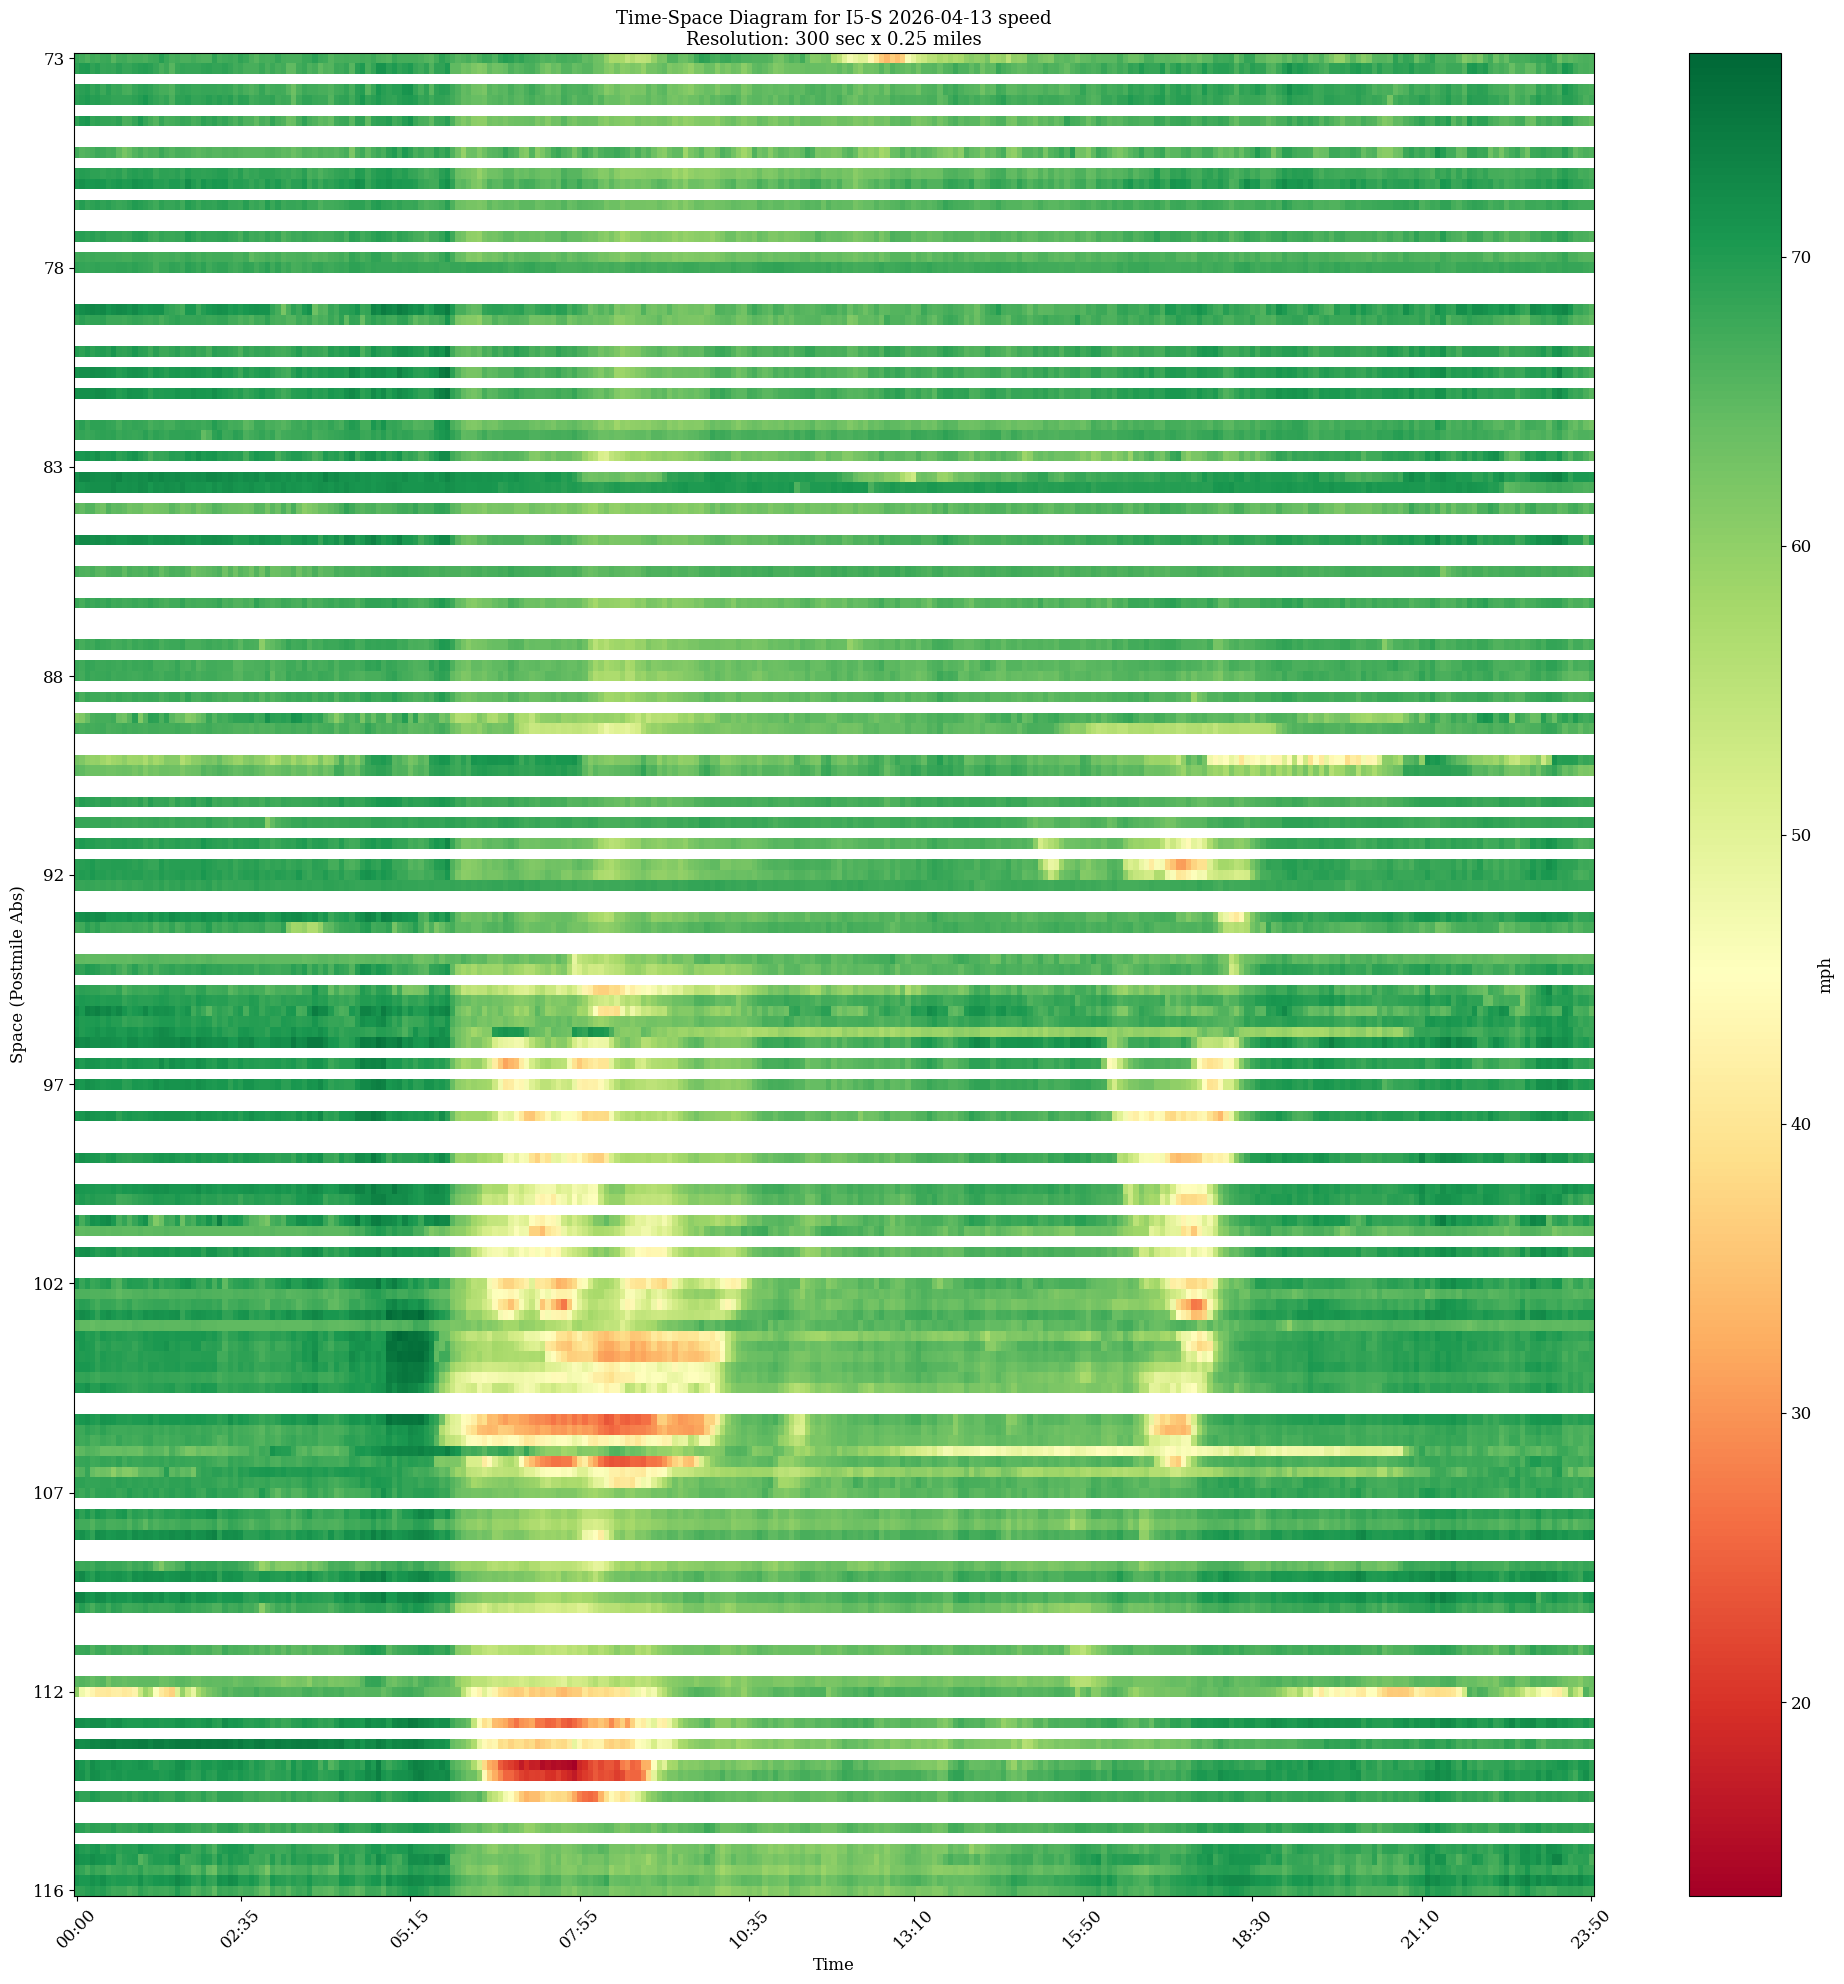

inferred time increment: 0 days 00:05:00
inferred space increment: -0.4 km
num time bins: 287
num space bins: 176
num space edges: 176


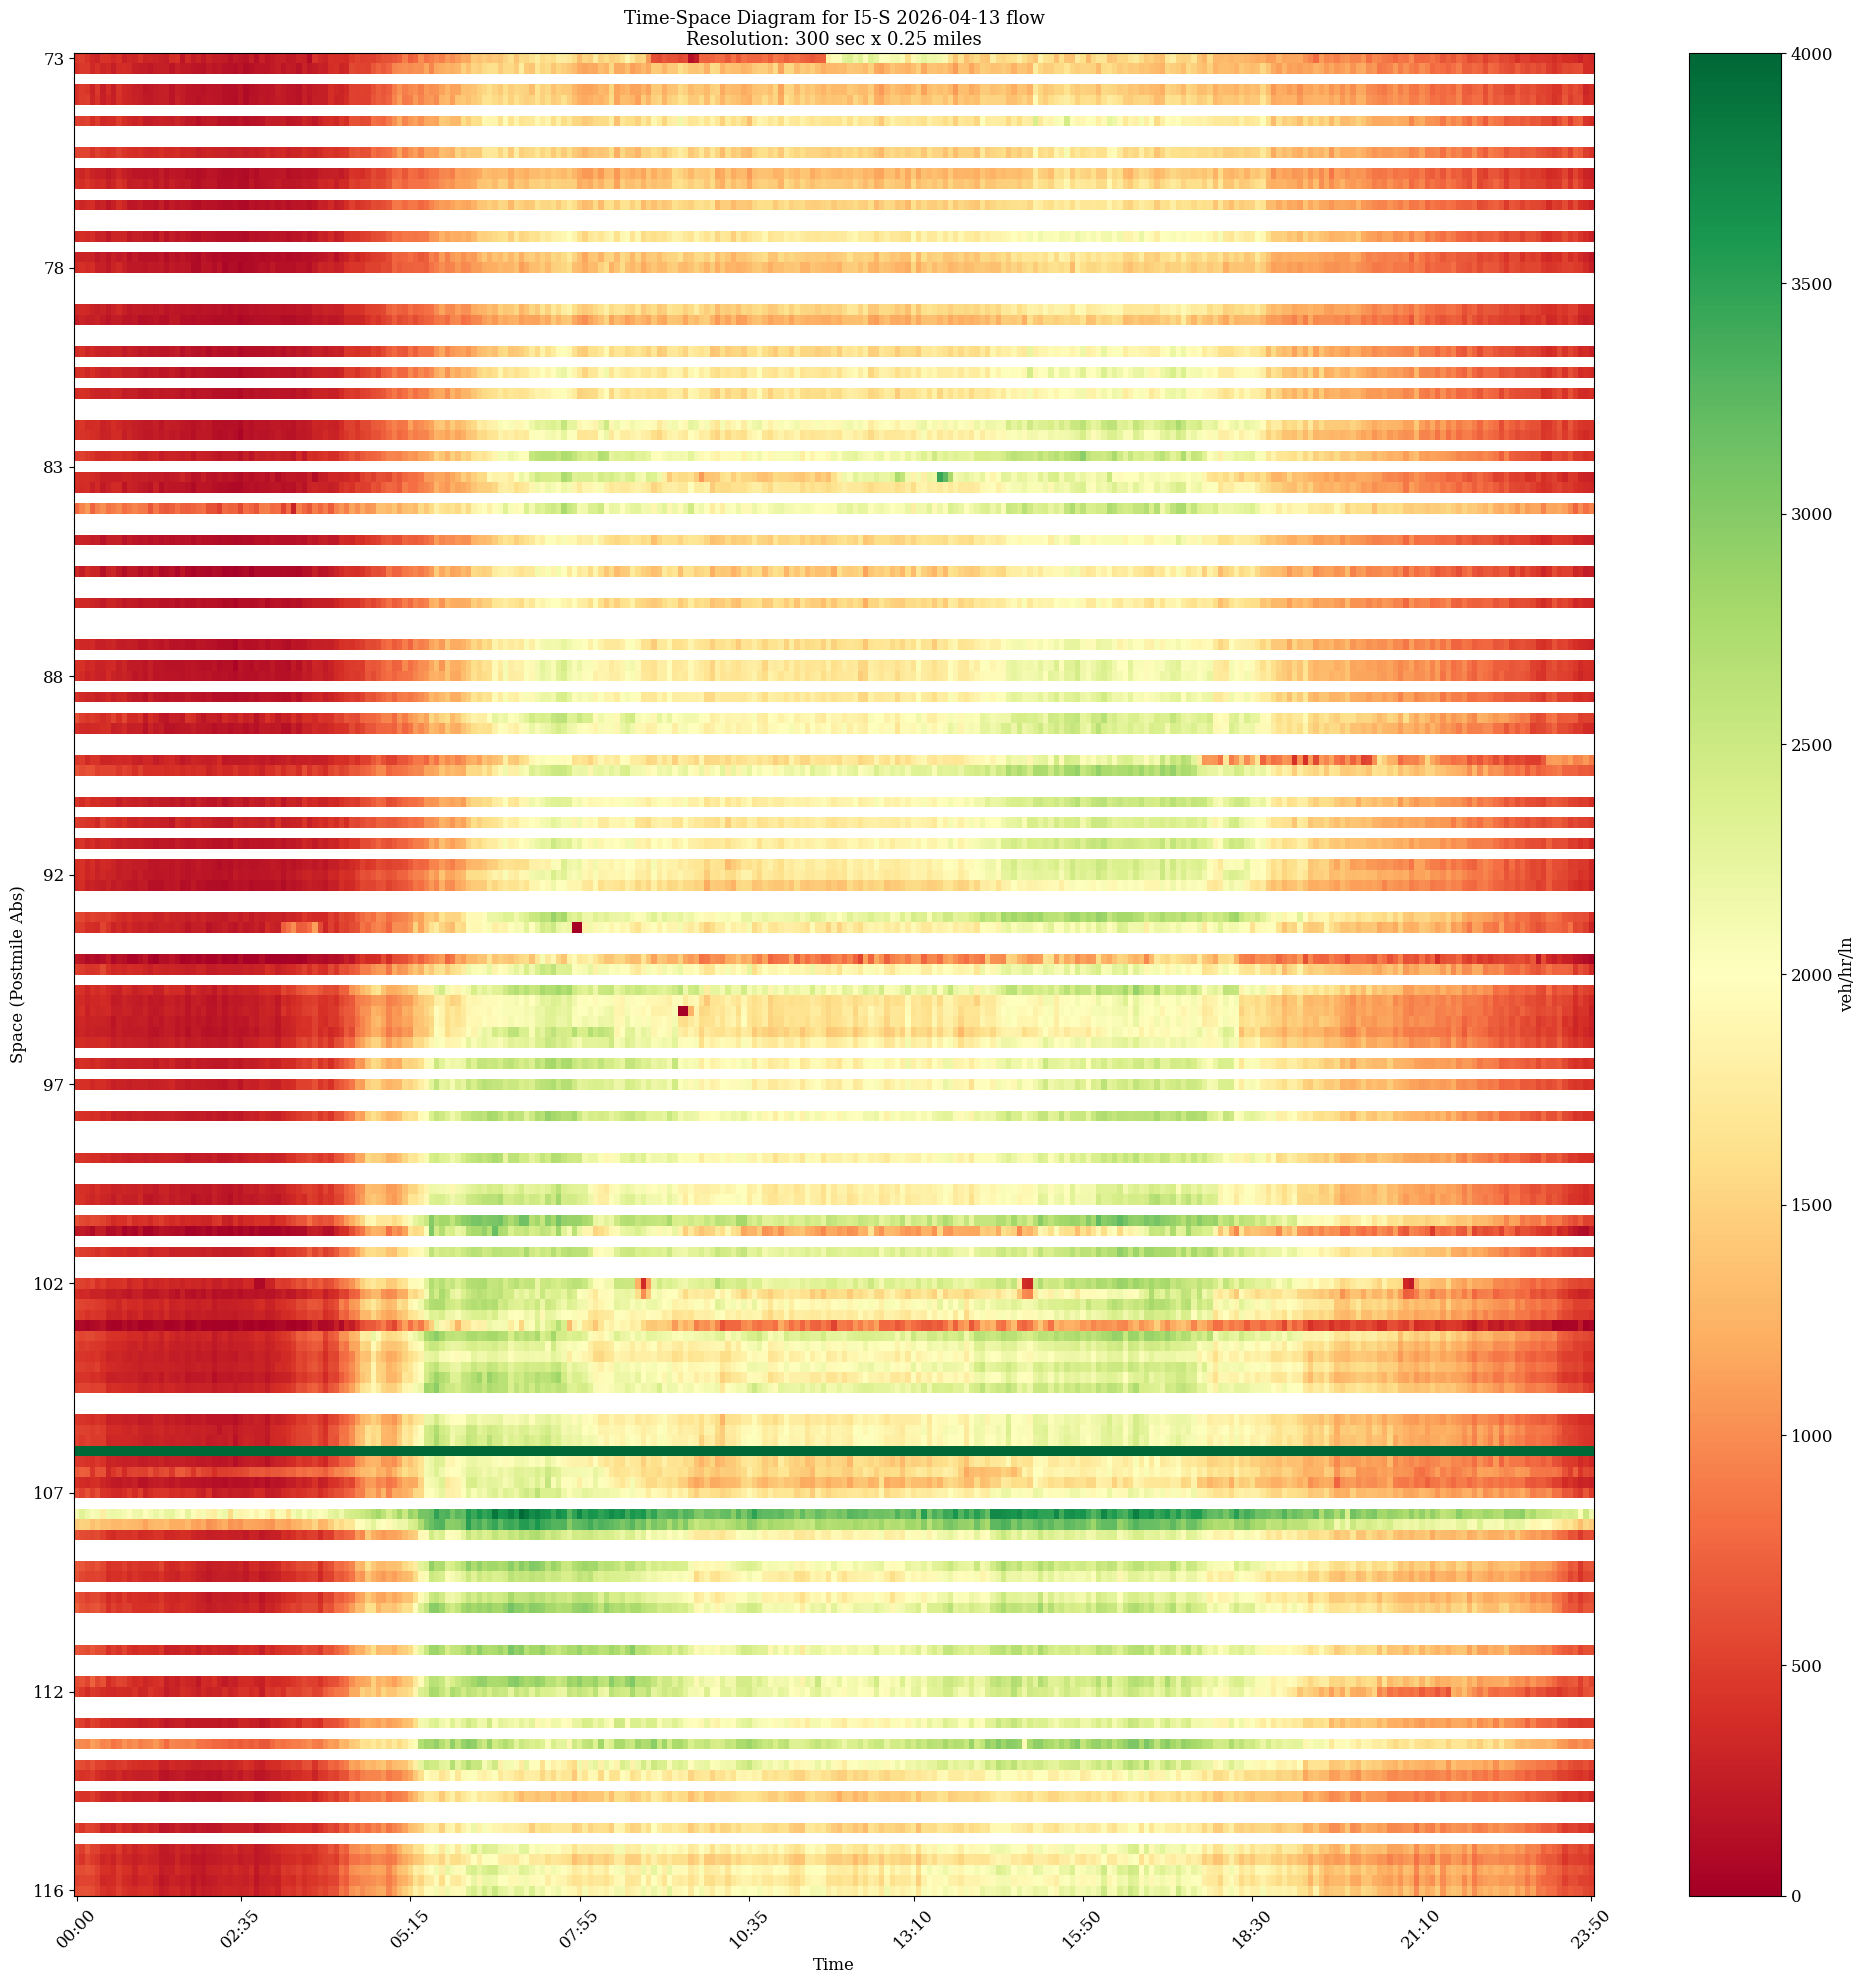

inferred time increment: 0 days 00:05:00
inferred space increment: 0.4 km
num time bins: 287
num space bins: 176
num space edges: 176


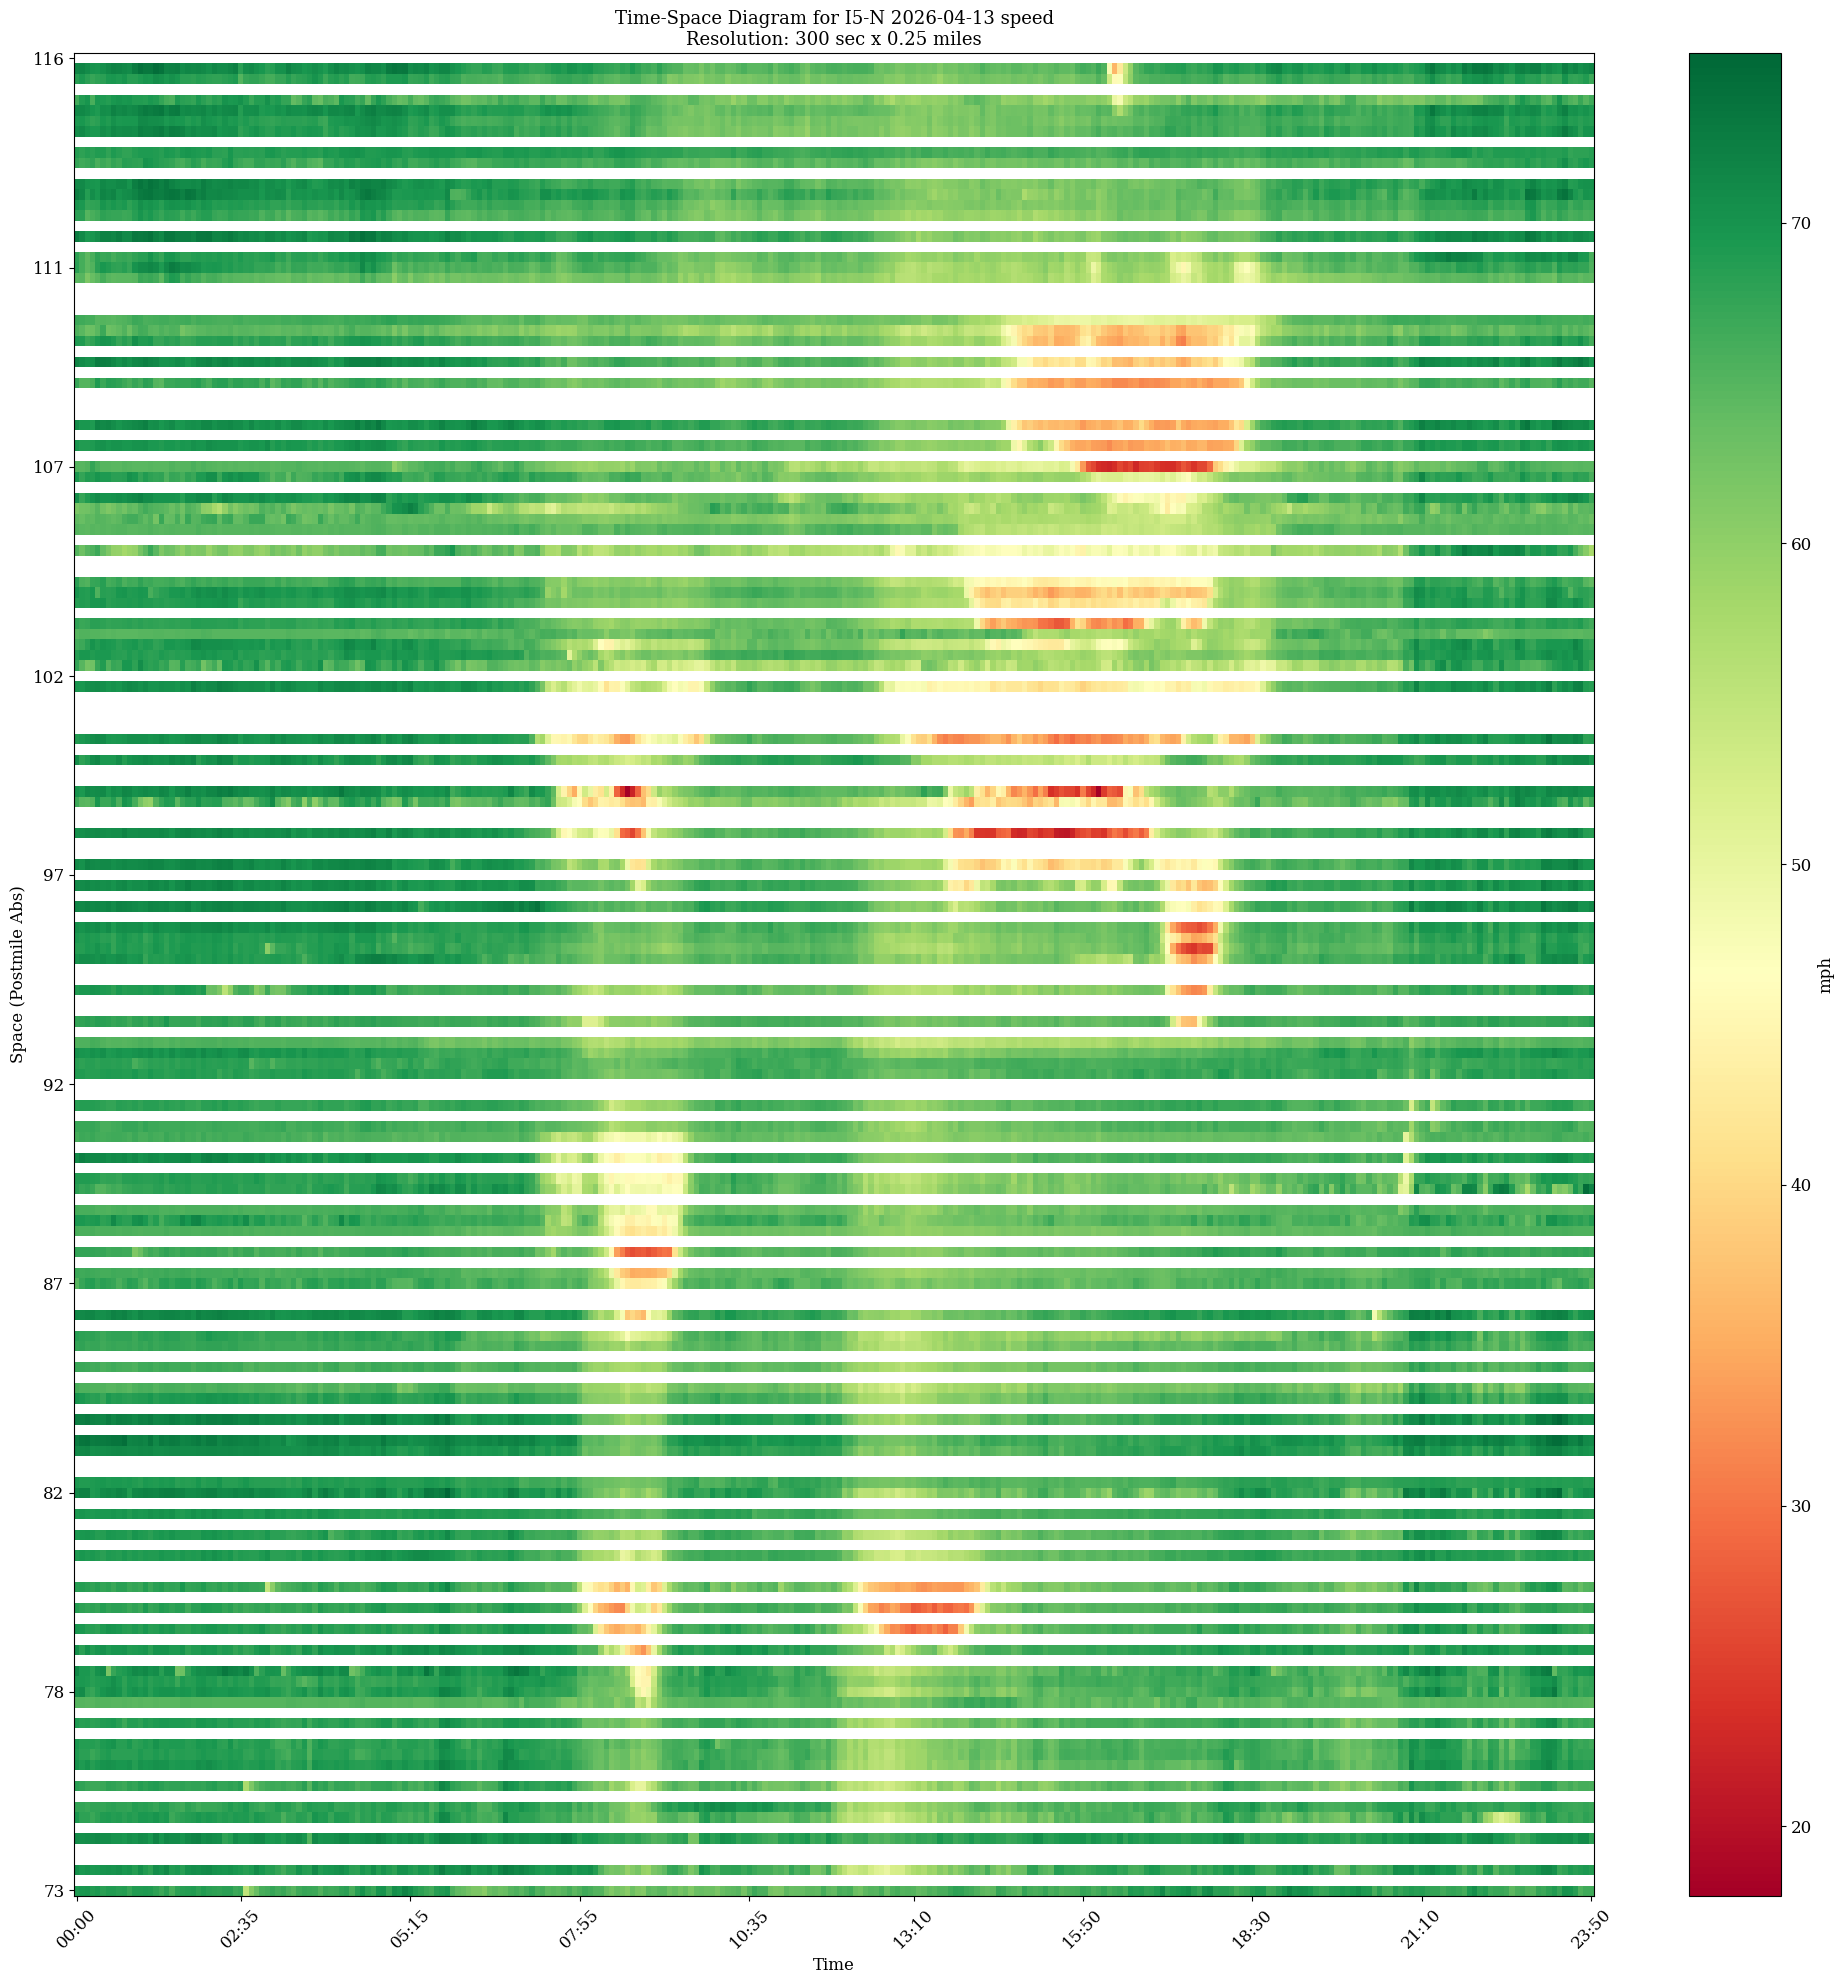

inferred time increment: 0 days 00:05:00
inferred space increment: 0.4 km
num time bins: 287
num space bins: 176
num space edges: 176


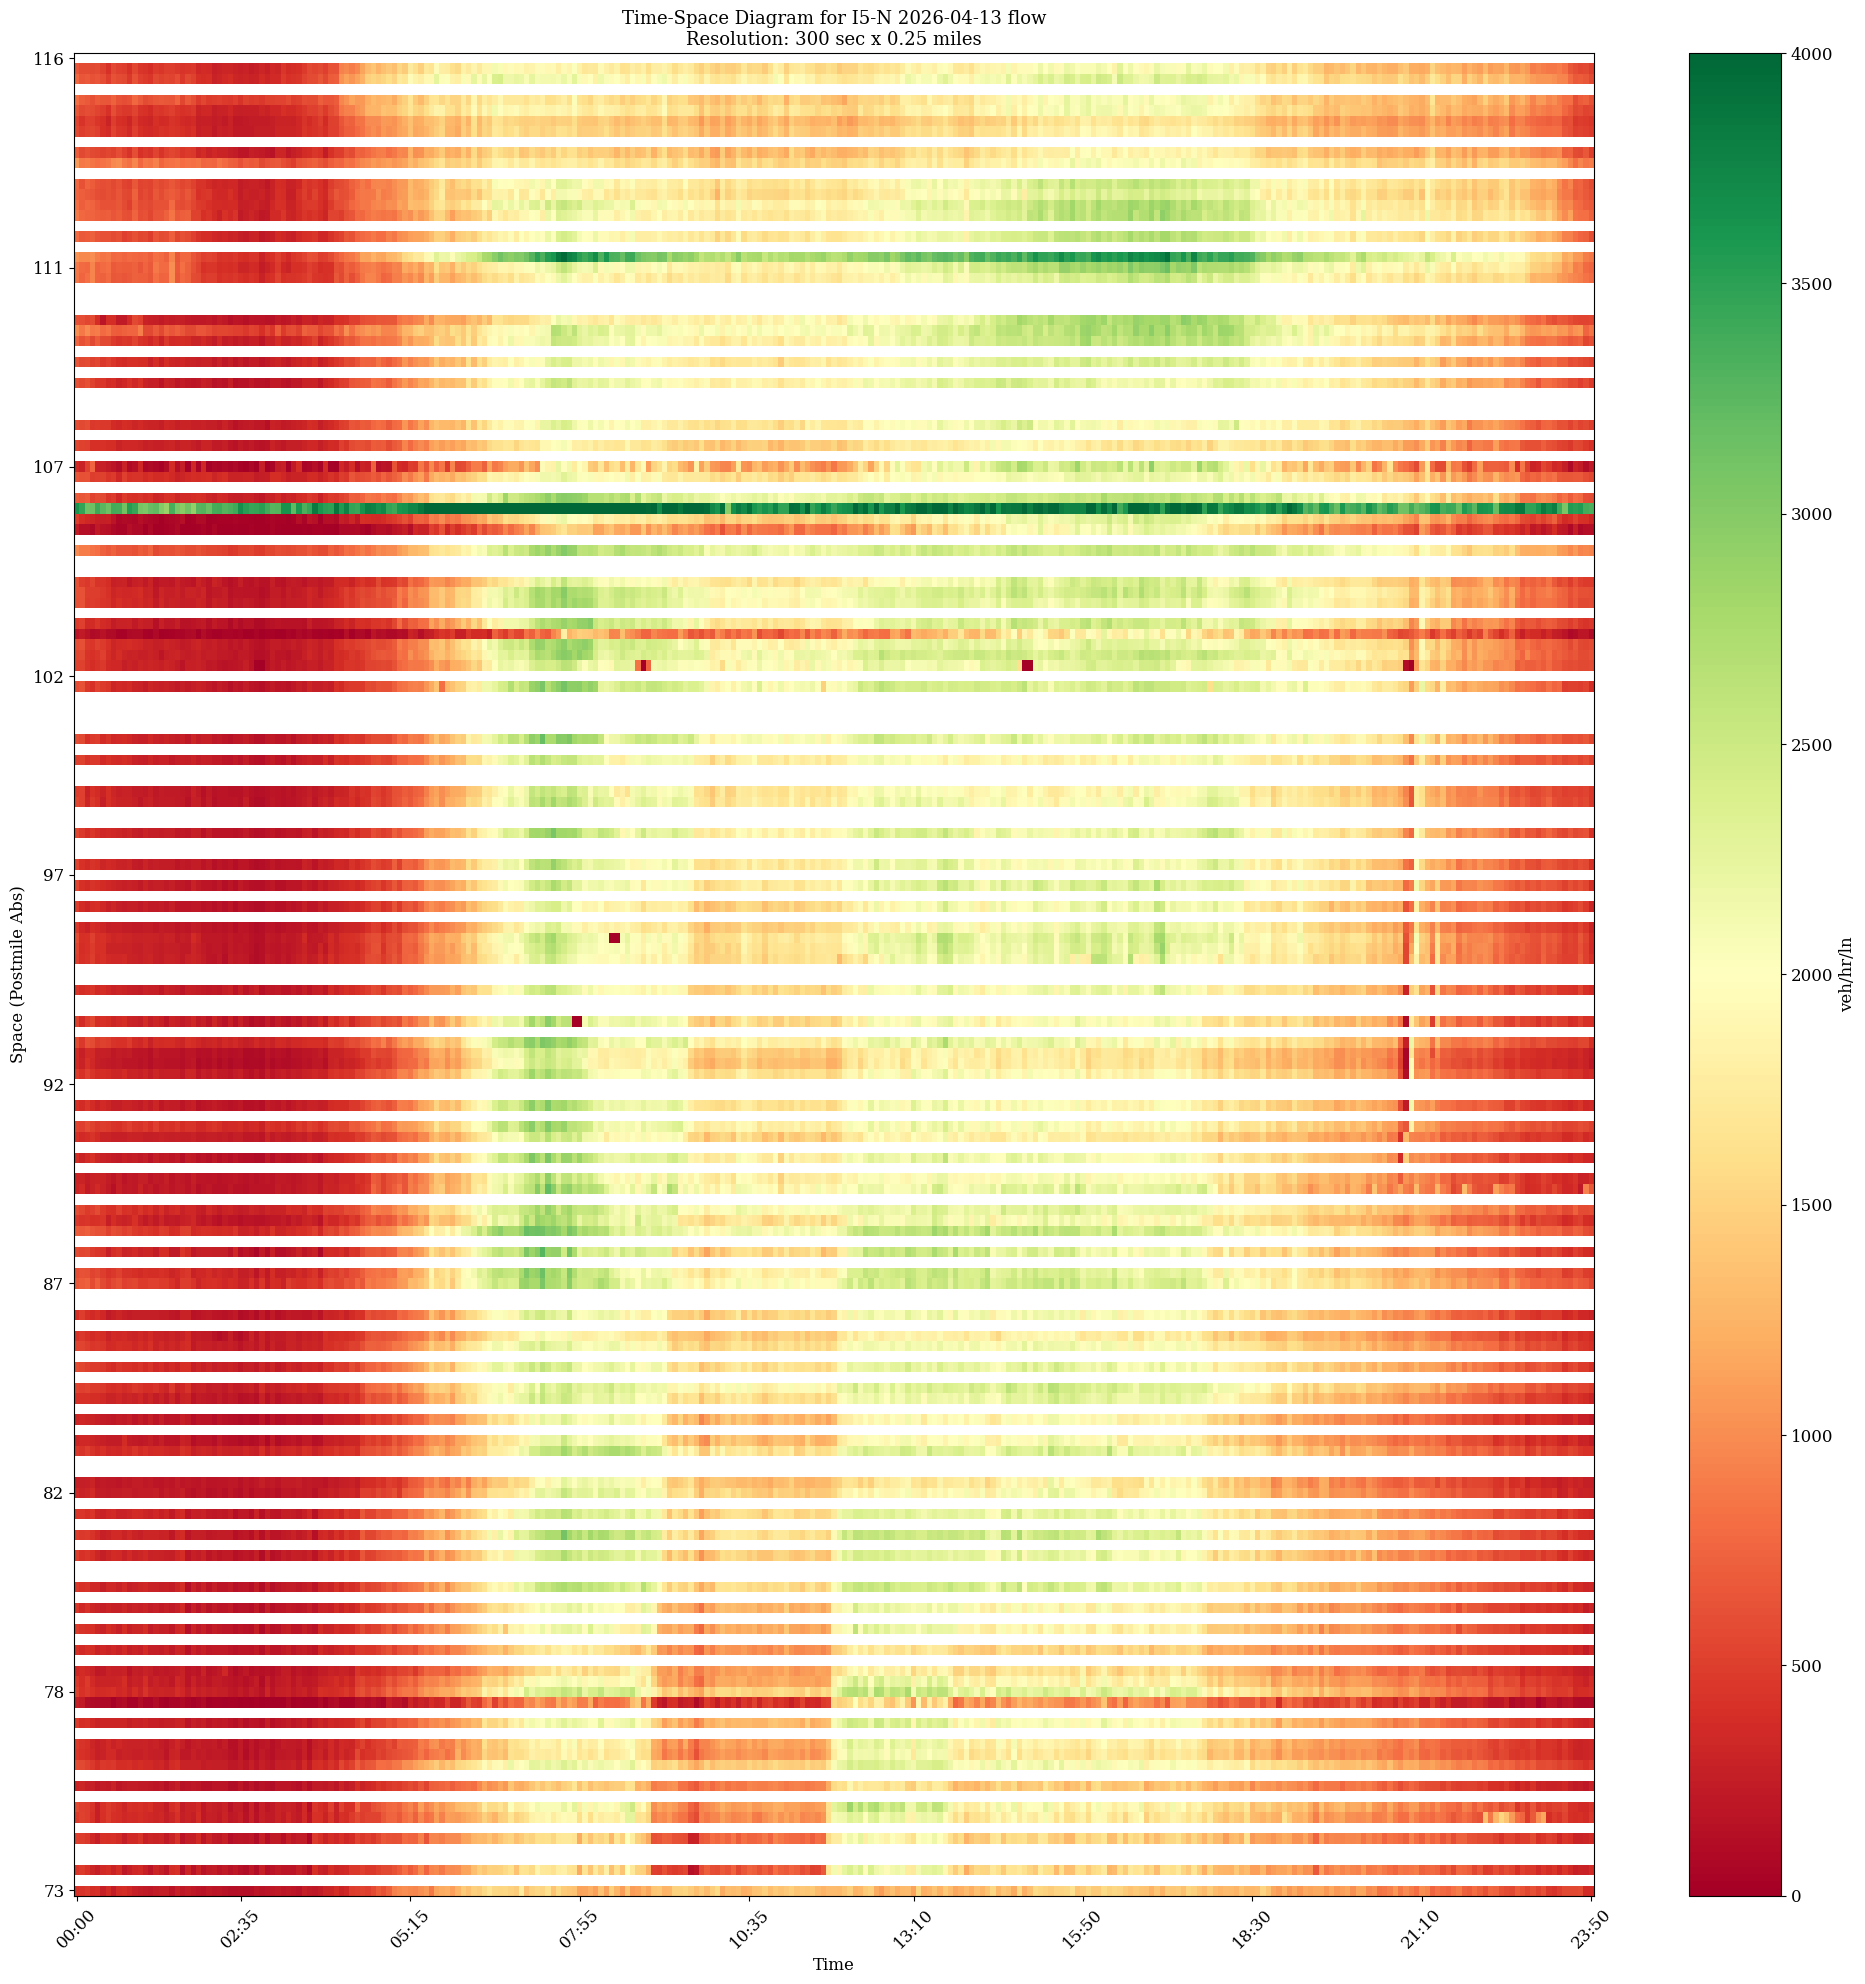

inferred time increment: 0 days 00:05:00
inferred space increment: 0.4 km
num time bins: 287
num space bins: 176
num space edges: 176


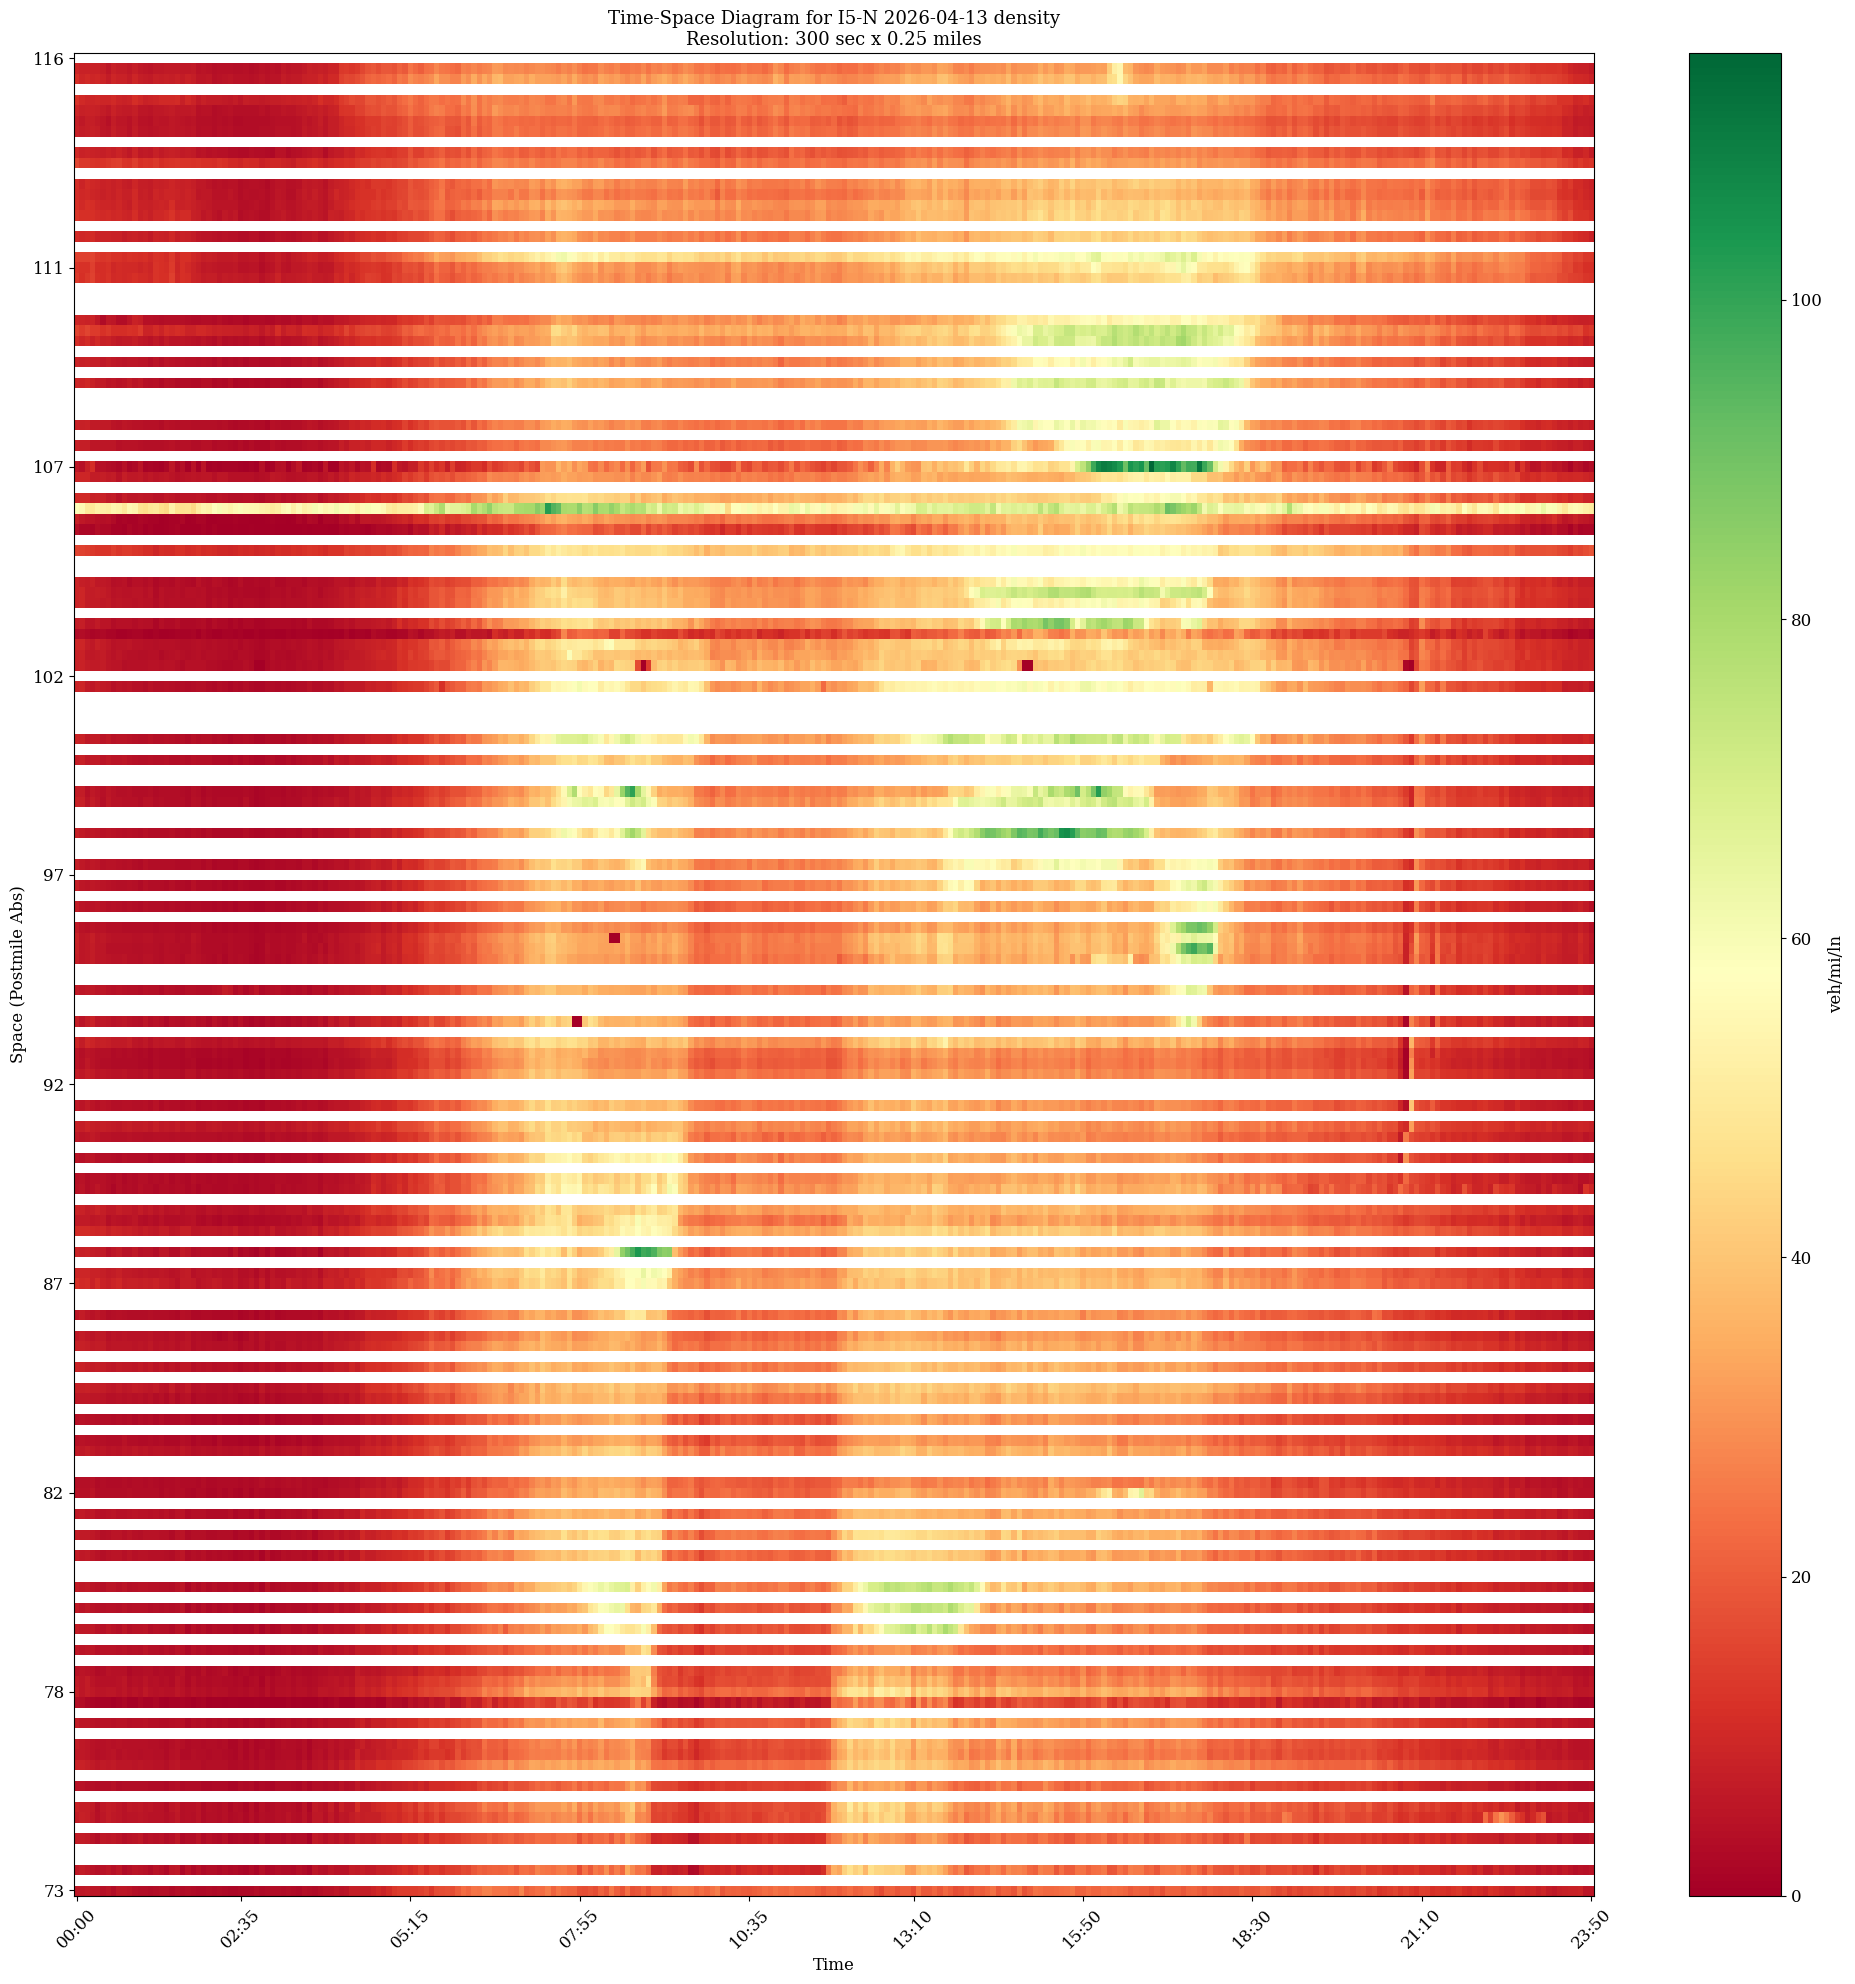

In [84]:
# --- PeMS gridding parameters -------------------------------------------------
time_increment_seconds = pd.Timedelta(seconds=5 * 60)
time_col = "timestamp"
postmile_col = "abs_pm"
start_pm = i5_s['abs_pm'].max()
end_pm = i5_s['abs_pm'].min()
SPACE_STEP_KM= 0.4 
SPACE_STEP_MI = SPACE_STEP_KM * 0.621371

i5_s_valid = i5_s_merged.dropna(subset=["timestamp", "abs_pm"]).copy()
i5_s_valid = i5_s_valid[i5_s_valid["timestamp"].dt.date == selected_date.date()].copy()

i5_n_valid = i5_n_merged.dropna(subset=["timestamp", "abs_pm"]).copy()
i5_n_valid = i5_n_valid[i5_n_valid["timestamp"].dt.date == selected_date.date()].copy()

if i5_s_valid.empty:
    raise ValueError(f"No cleaned rows remain for {selected_date.date()}")

t_min = i5_s_valid[time_col].min()
t_max = i5_s_valid[time_col].max()
print(t_min, t_max)

expected_time_bins = (t_max - t_min) / time_increment_seconds + 1
expected_space_bins = (max(start_pm, end_pm) - min(start_pm, end_pm)) / SPACE_STEP_MI
print(expected_time_bins, expected_space_bins)

i5_s_density_matrix, _ = process_pems(
    i5_s_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_density",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
    t_min=t_min,
    t_max=t_max,
)

i5_n_density_matrix, _ = process_pems(
    i5_n_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_density",
    start_pm=end_pm,
    end_pm=start_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
    t_min=t_min,
    t_max=t_max,
)

i5_s_speed_matrix, _ = process_pems(
    i5_s_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_speed",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
)

i5_n_speed_matrix, _ = process_pems(
    i5_n_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="avg_speed",
    start_pm=end_pm,
    end_pm=start_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
    t_min=t_min,
    t_max=t_max,
)

i5_s_flow_matrix, _ = process_pems(
    i5_s_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="flow_per_lane",
    start_pm=start_pm,
    end_pm=end_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
    t_min=t_min,
    t_max=t_max,
)

i5_n_flow_matrix, _ = process_pems(
    i5_n_valid,
    time_col=time_col,
    postmile_col=postmile_col,
    value_col="flow_per_lane",
    start_pm=end_pm,
    end_pm=start_pm,
    time_interval=time_increment_seconds,
    space_interval=SPACE_STEP_MI,
    t_min=t_min,
    t_max=t_max,
)

plot_matrix(
    i5_s_speed_matrix,
    f"I5-S {selected_date.date()} speed",
    "mph",
    t_min=t_min,
    t_max=t_max,
    start_pm=start_pm,
    end_pm=end_pm,
)

plot_matrix(
    i5_s_flow_matrix,
    f"I5-S {selected_date.date()} flow",
    "veh/hr/ln",
    t_min=t_min,
    t_max=t_max,
    start_pm=start_pm,
    end_pm=end_pm,
    colorbar_range=(0, 4000)
)

plot_matrix(
    i5_n_speed_matrix,
    f"I5-N {selected_date.date()} speed",
    "mph",
    t_min=t_min,
    t_max=t_max,
    start_pm=end_pm,
    end_pm=start_pm,
)

plot_matrix(
    i5_n_flow_matrix,
    f"I5-N {selected_date.date()} flow",
    "veh/hr/ln",
    t_min=t_min,
    t_max=t_max,
    start_pm=end_pm,
    end_pm=start_pm,
    colorbar_range=(0, 4000)
)

plot_matrix(i5_n_density_matrix, f"I5-N {selected_date.date()} density", "veh/mi/ln", t_min=t_min, t_max=t_max, start_pm=end_pm, end_pm=start_pm)

# selected_density_result = {
#     "density_matrix": density_matrix,
#     "density_df": density_df,
# }

In [85]:
# speed_matrix = np.asarray(speed_matrix, dtype=float)
# flow_matrix = np.asarray(flow_matrix, dtype=float)
np.save("data/pems/5_min/i5_s_speed_matrix_04_13", i5_s_speed_matrix)
np.save("data/pems/5_min/i5_s_flow_matrix_04_13", i5_s_flow_matrix)
np.save("data/pems/5_min/i5_n_speed_matrix_04_13", i5_n_speed_matrix)
np.save("data/pems/5_min/i5_n_flow_matrix_04_13", i5_n_flow_matrix)